### Notebook for estimating the impact of modeling the leaf as homogeneous vs heterogeneous over a range of parameters

The data stored in data/saved_data/sensitivies.txt reflects the heatmap of sensitivity $\eta(\tau,\gamma)$ as displayed in figure 3C.

In [1]:
import numpy as np 
from tqdm import tqdm # implementation of progress bars in jupyter notebooks
import sys 
sys.path.append('../../modules/')
import leaf_model as lm

100%|██████████| 100/100 [00:01<00:00, 84.44it/s]


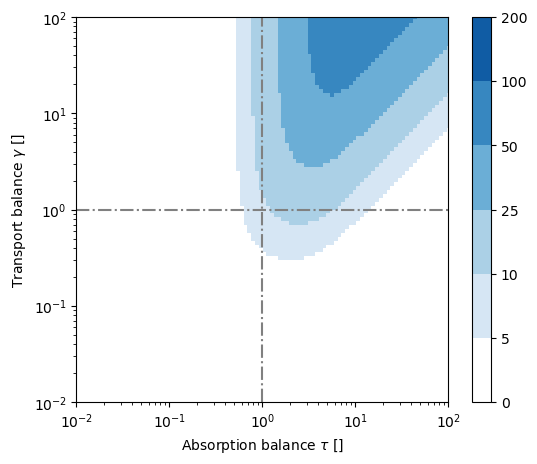

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import pandas as pd

def sensitivity_search(contrast=0.2, chi_=0.10, N=50):
    # set up mesh of parameters (tau, gamma), rho_deltas=D_PM/D_SM, rho_kappas=K_SM/K_PM, rho_lambdas=L_PM/L
    taus   = np.exp(np.linspace(np.log(0.01), np.log(100), N))
    gammas = np.exp(np.linspace(np.log(0.01), np.log(100), N))
    # initialize leaf model object 
    leaf_homo = lm.Leaf(1, 1, chi_, rho=(1, 1, 0.5))
    leaf_het = lm.Leaf(1, 1, chi_, rho=(1, contrast, 0.5))
    errors  = np.zeros((N,N)) # container for sensitivities \eta
    # loop over taus and gammas
    for i in tqdm(range(N)):
        for j in range(N):
            # update leaf model parameters
            leaf_het.tau   = taus[i]
            leaf_het.gamma = gammas[j]
            leaf_homo.tau   = taus[i]
            leaf_homo.gamma = gammas[j]
            # calculate homogeneous mesophyll solution
            _, sol_homo = leaf_homo.calculate_steady_state_solution()
            _, sol_het = leaf_het.calculate_steady_state_solution()
            #
            drawdown_homo = (1 - sol_homo[0])
            drawdown_het = (1 - sol_het[0])
            #
            error = np.abs(drawdown_homo - drawdown_het)/drawdown_het
            errors[i,j] = error
    return taus, gammas, errors.T #


def plot_map(ax: plt.Axes, map: np.ndarray, cmap: ListedColormap, norm: BoundaryNorm, vmin: float = 0.01, vmax: float = 100, inset: bool = False):
    """Helper function to set standard plot settings for (tau,gamma) figures."""
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(vmin, vmax)
    ax.set_ylim(vmin, vmax)
    ax.plot([1, 1], [vmin, vmax], color="grey", linestyle="-.", zorder=2)
    ax.plot([vmin, vmax], [1, 1], color="grey", linestyle="-.", zorder=2)
    
    N = map.shape[0]
    taus = np.exp(np.linspace(np.log(vmin), np.log(vmax), N))
    gammas = np.exp(np.linspace(np.log(vmin), np.log(vmax), N))
    im = ax.pcolormesh(taus, gammas, map, shading="nearest", cmap=cmap, norm=norm)    
    if not inset:
        ax.set_xlabel(r"Absorption balance $\tau$ []")
        ax.set_ylabel(r"Transport balance $\gamma$ []")
    else:
        ax.tick_params(axis="x", labelbottom=False)
        ax.tick_params(axis="y", labelleft=False)
    return im

def make_colormap(basis: str, bounds: list) -> tuple[ListedColormap, BoundaryNorm]:
    cmap = plt.get_cmap(basis, len(bounds))
    colors = cmap(range(len(bounds)-1))
    colors[0] = (1, 1, 1, 1)  # set the first color to white
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(bounds, cmap.N)
    return cmap, norm 


taus, gammas, errors = sensitivity_search(N=100)
errors *= 100
# np.savetxt('../saved_data/errors_only_K.txt', errors, delimiter=';')

cmap, norm = make_colormap("Blues", bounds=[0, 5, 10, 25, 50, 100, 200])
fig, ax = plt.subplots(figsize=(6, 5))
im = plot_map(ax, errors, cmap, norm)
cbar = fig.colorbar(im, ax=ax)
plt.show()
